# Exercise 7: Representation learning and XAI

Representation learning has been gaining significant attention over the past few years,
driven by the rise of new architectures and the growing need in biology to extract meaningful structured information
from increasingly high-dimensional and complex data. Yet as these models become more capable, understanding what they are actually learning becomes
just as important as their predictive performance, and that is precisely the role of explainable AI plays.

Goal of the exercises

The goal of this exercise is to first build an understanding of what representation learning is,
what we mean by a "representation" in that context, and what makes a representation good or useful.
From there, we will explore what architectures can be used to obtain these representations, and how we can evaluate
the quality of the obtained representations.  The second half of the exercise shifts focus to Explainable AI (XAI),
where the goal is to learn how to probe what a pre-trained classifier has learned about the data it was trained on.

In part A, we will be building two models from scratch.....

We will:
1.
2.
3.
4.

In part B, we will be working with a simple example which is a fun derivation on the MNIST dataset that you will have seen in previous exercises in this course.
Unlike regular MNIST, our dataset is classified not by number, but by color!

We will:
1. Load a pre-trained classifier and try applying conventional attribution methods
2. Train a GAN to create counterfactual images - translating images from one class to another
3. Evaluate the GAN - see how good it is at fooling the classifier
4. Create attributions from the counterfactual, and learn the differences between the classes.

If time permits, we will try to apply this all over again as a bonus exercise to a much more complex and more biologically relevant problem.
### Acknowledgments

This notebook was written by Diane Adjavon, Maria Theiss and Anna Foix-Romero with input from
Alex Hillsley, Ed Hirata, Larissa Heinrich, Morgan Schwartz, Anna Foix-Romero, Ben Salmon and Albert Dominguez.
Part B was inspired by a previous version written by Jan Funke and modified by Tri Nguyen, using code from Nils Eckstein.
Part A has been inspired by multiple discussions between Virginie Uhlhmann, Alex Krull, Martin Weigert,
Albert Dominguez, Ed Hirata and Anna Foix-Romero.


<div class="alert alert-danger">
Set your python kernel to <code>07_xai</code>
</div>


# PART A: Representation learning
## Part A.1: What is a "representation" and why is that useful?
## Part A.2: What does it mean "a good representation"?
## Part A.3: Unsupervised learning

## Part A.4: General set-up
In this part of the notebook, we will load the same dataset as in the previous exercise.
### Part A.4.1: The MNIST dataset
As a reminder, MNIST is benchmark datasets in machine learning, consisting of 70,000 grayscale images of handwritten digits
from 0 to 9, split into 60,000 for training and 10,000 for testing, where each image has a resolution of 28x28 pixels.
It is a great dataset to introduce representation learning because it is simple enough to train quickly,
but still structured enough that we can visually inspect and intuitively evaluate the quality of the learned representations
and reconstructions.

Documentation for this pytorch dataset is available at https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html

Let's get started and load our dataset, transforming the images into torch tensors and normalising them.

In [1]:
import torchvision
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor(), torchvision.transforms.Normalize((0.1307,), (0.3081,))])
train_mnist = torchvision.datasets.MNIST("./mnist", train=True, download=False, transform=transform)
test_mnist = torchvision.datasets.MNIST("./mnist", train=False, download=False, transform=transform)

<div class="alert alert-info">
    <b>Note:</b> set the <code>download</code> argument of <code>torchvision.datasets.MNIST</code> to <code>True</code> or <code>False</code> as required when re-running the notebook. When <code>./mnist</code> does not yet exist (on first run), make sure the first call to <code>torchvision.datasets.MNIST</code> has <code>download</code> set to <code>True</code>.
</div>

Let's take a look at a few loaded samples:

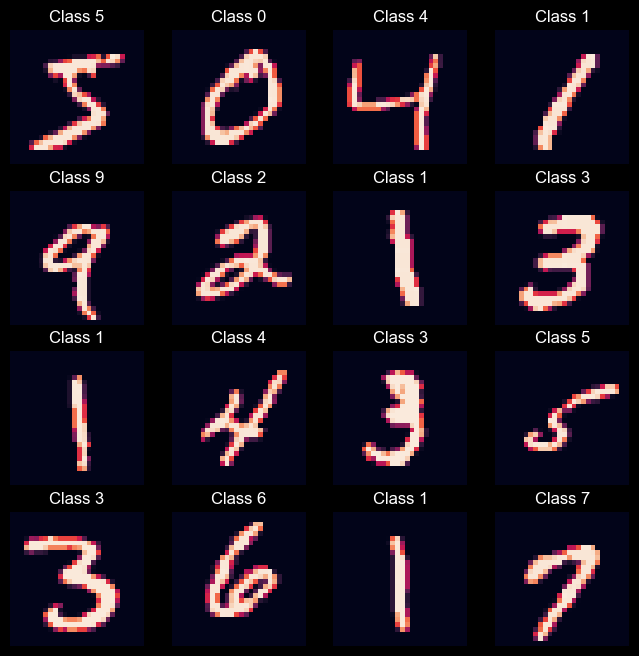

In [2]:
import matplotlib.pyplot as plt

# Show some examples
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axs.flatten()):
    x, y = train_mnist[i]
    x = x.permute((1, 2, 0))  # make channels last
    ax.imshow(x)
    ax.set_title(f"Class {y}")
    ax.axis("off")

Now, from the loaded datasets (both the train and test splits), we derive the dataloaders. We use dataloaders as they provide additional load-time features. Specifically, a dataloader enables iterating over the dataset in batches, and it also provides shuffling if desired. Here, we set the `batch_size` for both the train and test loader, and set `shuffle` for training only.

In [3]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_mnist, batch_size=8, shuffle=True)
test_loader = DataLoader(test_mnist, batch_size=8, shuffle=False)

Have a look at the shape of what the dataset iterator and the dataloader iterator differ:

In [4]:
smpl, lbl = next(iter(train_mnist))
print(f"dataset element shape: {smpl.shape} (class: {lbl})")
smpl, lbl = next(iter(train_loader))
print(f"dataloader element shape: {smpl.shape} (class: {lbl})")

dataset element shape: torch.Size([1, 28, 28]) (class: 5)
dataloader element shape: torch.Size([8, 1, 28, 28]) (class: tensor([6, 1, 3, 1, 8, 5, 1, 5]))


We note that dataloader elements come 8 at a time, with an extra "batch" dimension set to 8 as the first dimension in the tensor (and the labels being provided in a tensor of size 8 as opposed to a single value like in the dataset case). Also note that, both in the dataset and in the dataloader case, the data is not presented as a simple 2d 28x28 image, but rather as a 1x28x28 3d piece of data. This is useful when using multichannel data, but in our case, this extra dimension is superfluous. Keep this in mind when we use the data in the model for training, at which point we will explicitly drop this extra channel dimension.

### Part A.5: Autoencoders
Now, let's present the model we will use to train. An autoencoder is an machine learning architecture capable of learning a compressed representation of data by pushing it through a low-dimensional "bottleneck" and then expanding it back into its original size. The model is forced to rebuild with limited information, and must therefore learn to capture only the most important features, effectively performing non-linear dimensionality reduction. In our case, we convert `28 * 28 = 784` pixel images into a few core features only via the encoder part of the model. The decoder part then turns these few features back into `28 * 28` pixel images.

#### Part A.5.1: An MLP class for encoder and decoder
For this exercise, we chose a simple MLP (multi-layer perceptron) as the architecture to back both the encoder and the decoder. MLPs consist of linear transformations (weights and biases) followed by non-linear activation functions (ReLU) to learn. Here, we default to a single layer.

In [5]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__( self, input_dim, output_dim
                , hidden_dims=[], activation=nn.ReLU(), final_activation=True ):
        super().__init__()
        dims = [input_dim] + hidden_dims
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if activation is not None: layers.append(activation)
        layers.append(nn.Linear(dims[-1], output_dim))
        if final_activation and activation is not None:
            layers.append(activation)
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

#### Part A.5.2: The AutoEncoder class

Here we provide a simple AutoEncoder class making use of our previously defined MLP class for both its encoder and decoder. Note the encode function reshape the input, both dropping the unused channel dimension and reducing width and heigh to a single dimension, with a shape similar to that of the latent features, and outputs the encoded latent features.

The decoder consumes a latent feature vector and uses an MLP to reconstruct the original sample, reshaping as appropriate.

In [6]:
class AutoEncoder(nn.Module):
    def __init__( self, data_dim, latent_dim
                , enc_hidden_dims=[], enc_activation=nn.ReLU(), enc_final_activation=False
                , dec_hidden_dims=[], dec_activation=nn.ReLU(), dec_final_activation=False
                ):
        super().__init__()
        self.encoder = MLP( data_dim, latent_dim
                          , hidden_dims=enc_hidden_dims
                          , activation=enc_activation
                          , final_activation=enc_final_activation )
        self.decoder = MLP( latent_dim, data_dim
                          , hidden_dims=dec_hidden_dims
                          , activation=dec_activation
                          , final_activation=dec_final_activation )
    def encode(self, x):
        b, c, h, w = x.shape
        return self.encoder(x.reshape(b, -1))
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        b, c, h, w = x.shape
        z = self.encode(x)
        xx = self.decode(z)
        return xx.reshape(b, c, h, w), z

### Part A.5.3: The loss function
To train, we compute a Mean Squared Error "reconstruction" loss

In [7]:
loss = nn.MSELoss()

### Part A.5.4: Training
Now we get to create and train our model on the MNIST dataset.

#### Part A.5.4.1: Model instance and optimizer

We first create an instance of our AutoEncoder. On construction, it needs to know the size of the data it will receive and the desired latent space size. We grab a sample from the dataset to derive the appropriate size, and chose a latent dimension size as well (here, we compress by 10 the total size of the image).

In [8]:
data_sample, _ = next(iter(train_mnist))
_, w, h = data_sample.shape
model = AutoEncoder(data_dim=w*h, latent_dim=w*h//10)

We then create an optimizer for the model's parameters. It will be used during training to hold on to the gradients which will be computed from the backpropagation pass and eventually used to update the model's parameters appropriately.

In [9]:
from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=0.0001)

#### Part A.5.4.2: The training "loop"
To train a model, the general idea is to iterate through the dataset, passing each element through the model to produce a reconstruction, observe how close to the original data the reconstruction is using a loss function, and use that observation to inform the model optimisation. Performing these steps going once through all the training data is what is referred to as a training "epoch". We then loop this process over for a desired arbitrary number of training epochs.

Below is a function to capture training for a single epoch and which returns the average epoch loss, as well as a function that loops over the behaviour for a desired number of epochs. Note the `epoch_losses` list which will accumulate the average epoch losses as training occurs. We will use it to visualise the loss later.

In [10]:
def train_epoch(model, loader, optimizer, loss):
    model.train()
    running_loss = 0.0
    for x, _ in loader:
        xx, _ = model(x)
        l = loss(x, xx)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        # Stats
        running_loss += l.item()
        #print(f"running loss: {running_loss:.4f}, instant loss: {l.item()}, loader len: {len(loader)}")
    # average loss for epoch
    return running_loss / len(loader)

epoch_losses = []

from tqdm import tqdm
from itertools import islice

def train_epochs(n, model, loader, optimizer, loss):
    for epoch in range(n):
        # (Note: the `islice` is simply to train on only 100 elements and go faster. remove it for more data. The `tqdm` is just the progress bar.)
        fresh_loader_iter = iter(loader)
        sliced_loader = tqdm(islice(fresh_loader_iter, 100), total=100)
        avg_loss = train_epoch(model, sliced_loader, optimizer, loss)
        epoch_losses.append(avg_loss)
        tqdm.write(f"Epoch {epoch+1} Complete. Avg Loss: {avg_loss:.4f}")

We can now train the model. Let's do this for one epoch.

In [11]:
train_epochs(1, model, train_loader, optimizer, loss)

100%|██████████| 100/100 [00:00<00:00, 375.90it/s]

Epoch 1 Complete. Avg Loss: 0.9389


Now let's look at what reconstructions look like at this stage. Below are a couple simple visualisation function to display original and reconstructed images together, and to query the model for a batch of reconstructions and display them using the first function.

In [12]:
def show_recon(og, recon):
    """
    og and recon: Tensors of shape (B, 1, 28, 28) or (B, 784)
    """
    b, c, h, w = og.shape
    og = og.view(-1, h, w).detach().cpu()
    recon = recon.view(-1, h, w).detach().cpu()

    fig, axes = plt.subplots(nrows=2, ncols=b, figsize=(b * 1.5, 3))

    for i in range(b):
        # Top row: Original
        axes[0, i].imshow(og[i], cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Original")

        # Bottom row: Reconstruction
        axes[1, i].imshow(recon[i], cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Recon")

    plt.show()

import torch
def view_test_sample(model, loader):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(loader))
        recon, _ = model(images)
    show_recon(images, recon)

Let's call this on our model as it currently stands.

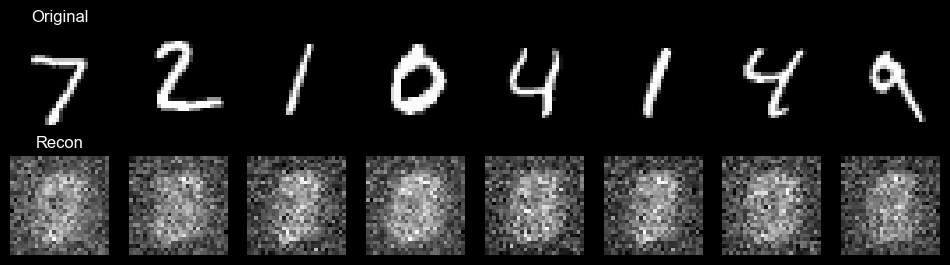

In [13]:
view_test_sample(model, test_loader)

Not the most beautiful sight just yet... Let's train some more...

100%|██████████| 100/100 [00:00<00:00, 512.42it/s]


Epoch 1 Complete. Avg Loss: 0.7066


100%|██████████| 100/100 [00:00<00:00, 517.29it/s]


Epoch 2 Complete. Avg Loss: 0.6425


100%|██████████| 100/100 [00:00<00:00, 544.37it/s]


Epoch 3 Complete. Avg Loss: 0.5819


100%|██████████| 100/100 [00:00<00:00, 541.70it/s]


Epoch 4 Complete. Avg Loss: 0.5324


100%|██████████| 100/100 [00:00<00:00, 517.47it/s]


Epoch 5 Complete. Avg Loss: 0.4888


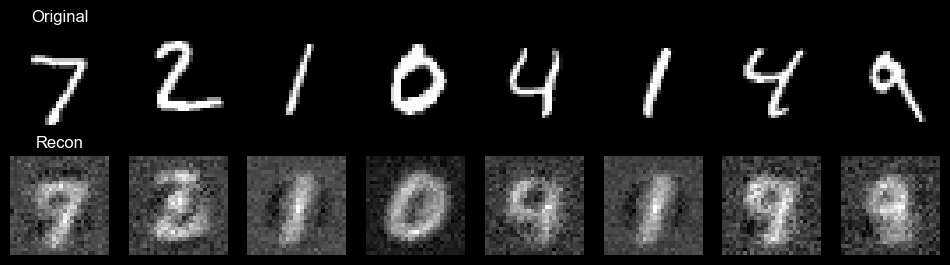

In [14]:
train_epochs(5, model, train_loader, optimizer, loss)
view_test_sample(model, test_loader)

A little more...

100%|██████████| 100/100 [00:00<00:00, 525.12it/s]


Epoch 1 Complete. Avg Loss: 0.4576


100%|██████████| 100/100 [00:00<00:00, 539.55it/s]


Epoch 2 Complete. Avg Loss: 0.4361


100%|██████████| 100/100 [00:00<00:00, 531.67it/s]


...

Epoch 48 Complete. Avg Loss: 0.1630


100%|██████████| 100/100 [00:00<00:00, 542.48it/s]


Epoch 49 Complete. Avg Loss: 0.1573


100%|██████████| 100/100 [00:00<00:00, 542.75it/s]


Epoch 50 Complete. Avg Loss: 0.1609


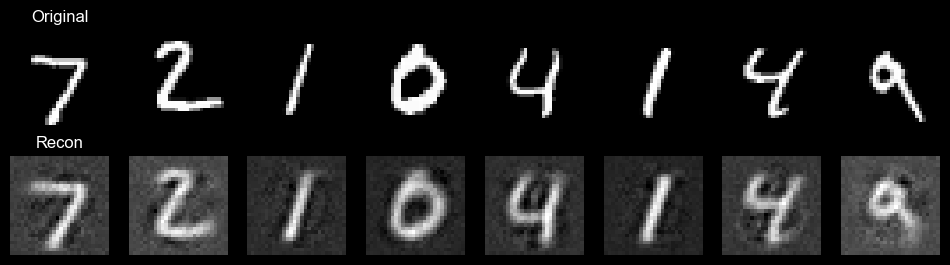

In [15]:
train_epochs(50, model, train_loader, optimizer, loss)
view_test_sample(model, test_loader)

Not bad :) Let's have a look at that loss.
Below is a simple function to plot it from the list we have accumulated in `epoch_losses` as we've trained.

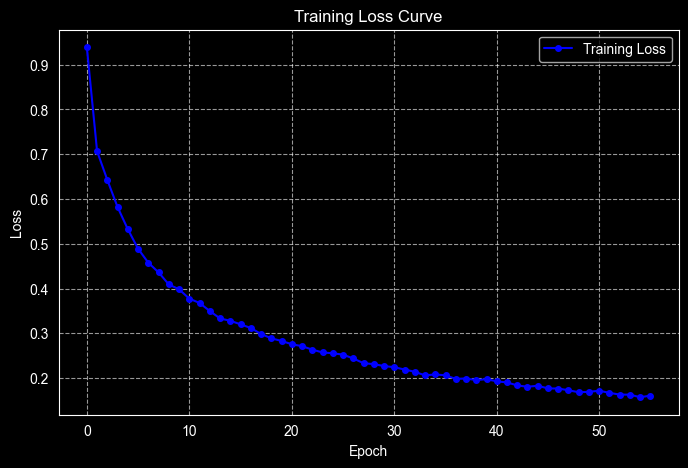

In [16]:
import numpy as np
def plot_loss(losses):
    plt.figure(figsize=(8, 5))
    plt.plot(losses, label='Training Loss', color='blue', marker='o', markersize=4)

    plt.title("Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Ensure x-axis shows integer epoch numbers
    #plt.xticks(range(len(losses)))
    plt.xticks(np.arange(0, len(losses) + 1, 10))

    plt.show()

plot_loss(epoch_losses)

We can clearly see it dropping as the training epochs happen and the model's parameters get optimised.

### Part A.5.5: Test
#### Part A.5.5.1: Visualise our latent space

In [17]:
def get_latent_features(model, loader):
    model.eval()
    latents = []
    labels = []

    with torch.no_grad():
        for x, lbl in loader:
            z = model.encode(x)
            latents.append(z)
            labels.append(lbl)
    return torch.cat(latents, dim=0), torch.cat(labels, dim=0)

In [18]:
from sklearn.manifold import TSNE

def plot_tsne( latents, labels
             , n_components=2
             , random_state=42
             , init='pca'
             , learning_rate='auto'
             , cmap='tab10', alpha=0.6, s=10 ):
    tsne = TSNE(n_components=n_components, random_state=random_state, init=init, learning_rate=learning_rate)
    z_2d = tsne.fit_transform(latents.numpy())

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap=cmap, alpha=alpha, s=s)

    plt.colorbar(scatter, ticks=range(10))
    #plt.title("t-SNE visualization of MNIST Latent Space")
    plt.axis('off')
    plt.show()

100%|██████████| 1250/1250 [00:00<00:00, 1799.00it/s]


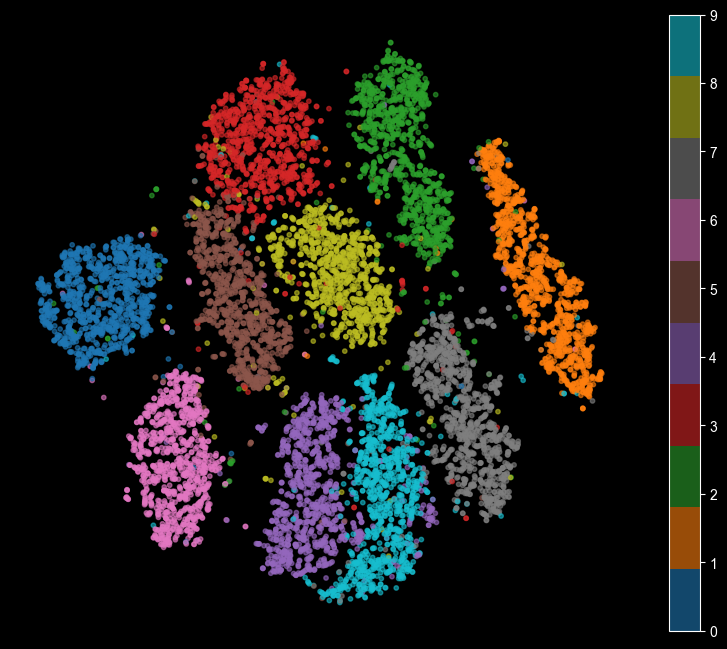

In [19]:
zs, lbls = get_latent_features(model, tqdm(test_loader))
plot_tsne(zs, lbls)

### Part A.5.5.2 Test quantitatively using a downstream task



## Part A.6: Contrastive learning
A.6.1 What is contrastive learning? (what is it, key parts, data augmentation, feature extraction, project network and objective)
A.6.2 Popular contrastive approaches
A.6.3 The two losses depending on if we have negative example sor not (NT-Xent loss if hard negative) (Cosine similarity of not hard negative)
A.6.3 Hands-on approach: SimCLR

### The simCLR loss function

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def simCLRLoss(z_i, z_j, temperature=0.5):
    """
    NT-Xent loss for SimCLR.
    Optimized to compute the similarity matrix for all pairs in a single batch.

    z_i, z_j: Projections from two different augmentations of the same batch.
    Shape: (batch_size, z_dim)
    """
    batch_size = z_i.shape[0]

    # Normalize projections to compute Cosine Similarity via dot product
    z_i = F.normalize(z_i, dim=1)
    z_j = F.normalize(z_j, dim=1)

    # 2. Represent all samples: [z_i_1, ..., z_i_N, z_j_1, ..., z_j_N]
    representations = torch.cat([z_i, z_j], dim=0)  # Shape: (2N, z_dim)

    # Compute Similarity Matrix (2N x 2N)
    # Each entry (i, j) is the cosine similarity between sample i and sample j
    sim_matrix = torch.mm(representations, representations.t()) / temperature

    # Create Mask to isolate positive pairs and remove self-similarities
    # Positive pairs are at (i, i+N) and (i+N, i)
    sim_ij = torch.diag(sim_matrix, batch_size)
    sim_ji = torch.diag(sim_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji], dim=0)  # Shape: (2N)

    # Denominator: Sum of exponentials of all pairs except self-similarity
    mask = (~torch.eye(2 * batch_size, device=sim_matrix.device).bool())
    negatives = sim_matrix[mask].view(2 * batch_size, -1)  # Shape: (2N, 2N-1)

    # Loss Calculation (Log-Sum-Exp trick for numerical stability)
    # Using CrossEntropy logic: -log( exp(pos) / sum(exp(all_neg_and_pos)) )
    logits = torch.cat([positives.unsqueeze(1), negatives], dim=1)
    labels = torch.zeros(2 * batch_size, device=z_i.device, dtype=torch.long)

    loss = F.cross_entropy(logits, labels)

    return loss

### The simCLR model

In [27]:

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class SimCLRModel(nn.Module):
    def __init__(self, input_channels=1, z_dim=128):
        super().__init__()

        # 1. Base Encoder (ResNet18)
        # We replace the first conv to handle grayscale and strip the final FC layer
        self.encoder = resnet18(weights=None)
        self.encoder.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.encoder.maxpool = nn.Identity()  # Common for smaller images (CIFAR/MNIST size)

        # Capture the output dimension of the ResNet backbone (usually 512)
        h_dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        # 2. Projection Head (MLP)
        # SimCLR papers suggest a non-linear projection head improves representation quality
        self.projector = nn.Sequential(
            nn.Linear(h_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, z_dim)
        )

    def forward(self, x):
        # h: representation (used for downstream tasks)
        # z: projection (used for the contrastive loss)
        h = self.encoder(x)
        z = self.projector(h)
        return h, z

### A new dataloader producing augmented views on the data

In [28]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
# SimCLR works best when the two "views" are slightly different
simclr_transform = T.Compose([
    # Randomly rotate the digit (e.g., ±15 degrees)
    T.RandomRotation(15),
    # Randomly shift the digit slightly
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    # Convert to tensor and use your existing normalization
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

class ContrastiveMNIST(Dataset):
    def __init__(self, base_dataset, transform = simclr_transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.base_dataset[index]
        # If img is already a tensor, convert back to PIL for augmentations
        if isinstance(img, torch.Tensor):
            img = torchvision.transforms.ToPILImage()(img)

        # Create two different augmentations
        x_i = self.transform(img)
        x_j = self.transform(img)
        return x_i, x_j, label

    def __len__(self):
        return len(self.base_dataset)

### A new training function that deals with data augmentation
We redefine our `train_epoch` and `train_epochs` from the previous exercise to deal with the two augmented views on
the data required in constrastive learning approaches.

In [29]:

import torch
from tqdm import tqdm
from itertools import islice

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    # unpack x1 (view 1), x2 (view 2), and ignore labels (_)
    for x1, x2, _ in loader:
        x1, x2 = x1.to(device), x2.to(device)

        # Forward pass: get projections (z) for both views
        _, z1 = model(x1)
        _, z2 = model(x2)

        # Calculate SimCLR loss
        loss_val = criterion(z1, z2)

        # Optimization
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Stats
        running_loss += loss_val.item()

    return running_loss / len(loader)

epoch_losses = [] # reset list of accumulated losses
def train_epochs(n, model, loader, optimizer, criterion, device):
    for epoch in range(n):
        # Using islice to speed up the showcase exercise
        fresh_loader_iter = iter(loader)
        limit = 50
        sliced_loader = tqdm(islice(fresh_loader_iter, limit), total=limit, desc=f"Epoch {epoch + 1}")

        avg_loss = train_epoch(model, sliced_loader, optimizer, criterion, device)
        epoch_losses.append(avg_loss)

        tqdm.write(f"Epoch {epoch + 1} Complete. Avg Loss: {avg_loss:.4f}")
    return epoch_losses

### And now we train

Epoch 1: 100%|██████████| 50/50 [01:02<00:00,  1.24s/it]


Epoch 1 Complete. Avg Loss: 3.1763


Epoch 2: 100%|██████████| 50/50 [01:00<00:00,  1.21s/it]


Epoch 2 Complete. Avg Loss: 2.9100


Epoch 3: 100%|██████████| 50/50 [01:03<00:00,  1.27s/it]


...

Epoch 18 Complete. Avg Loss: 2.5022


Epoch 19: 100%|██████████| 50/50 [00:59<00:00,  1.18s/it]


Epoch 19 Complete. Avg Loss: 2.5012


Epoch 20: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]

Epoch 20 Complete. Avg Loss: 2.4957


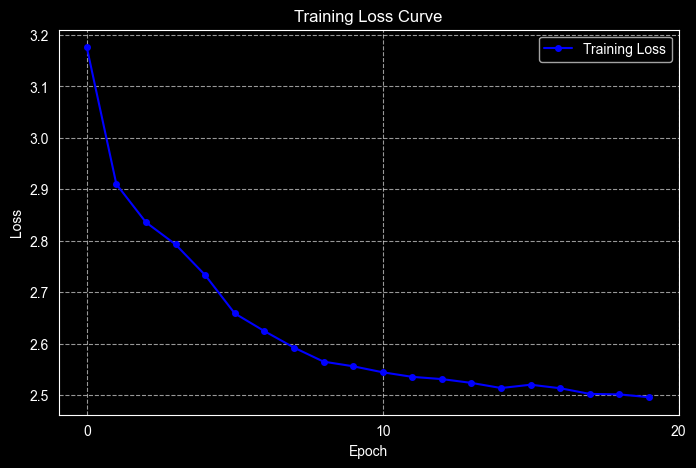

In [30]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimCLRModel(input_channels=1, z_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
contrastive_train = ContrastiveMNIST(train_mnist, transform=simclr_transform)
train_loader = torch.utils.data.DataLoader(contrastive_train, batch_size=32, shuffle=True)

losses = train_epochs(20, model, train_loader, optimizer, simCLRLoss, device)

plot_loss(epoch_losses)

100%|██████████| 1250/1250 [00:28<00:00, 43.12it/s]


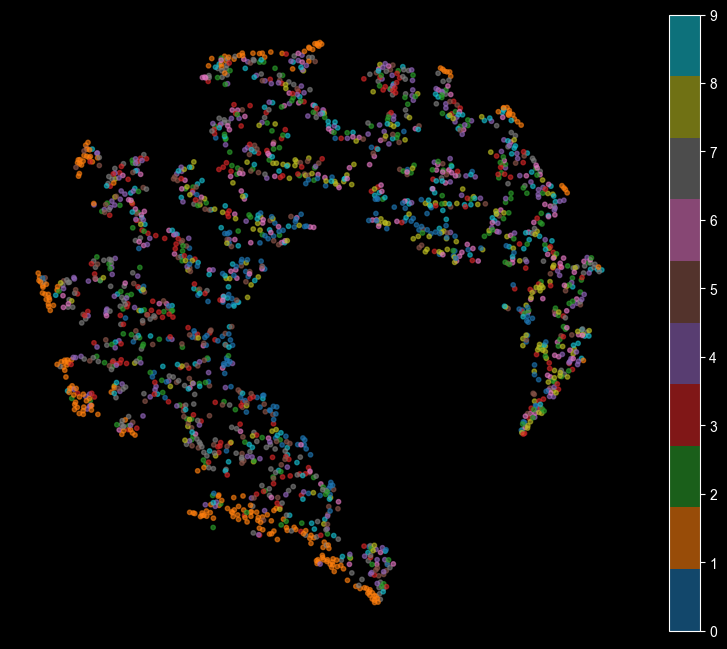

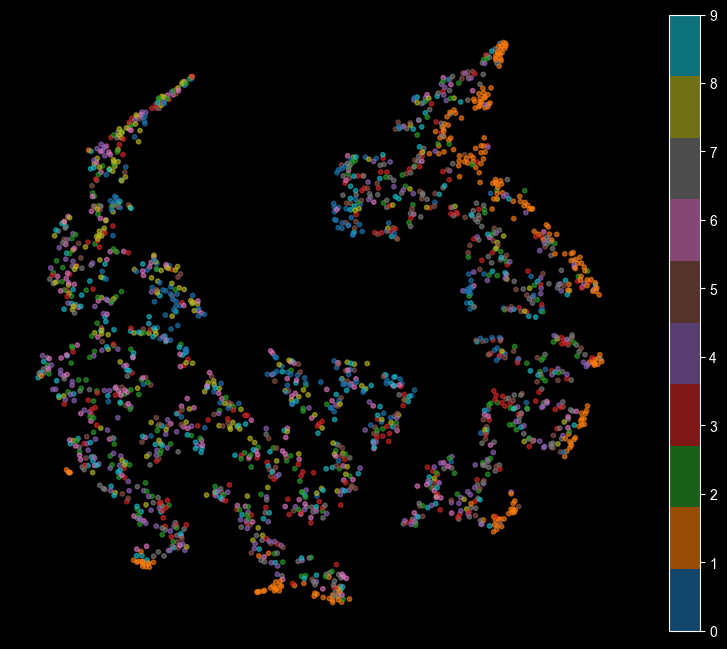

In [36]:
def get_latent_features(model, loader):
    model.eval()
    latents_h, latents_z = [], []
    labels = []

    with torch.no_grad():
        for x, lbl in tqdm(loader):
            h, z = model(x)
            latents_z.append(z)
            latents_h.append(h)
            labels.append(lbl)
    return torch.cat(latents_h, dim=0), torch.cat(latents_z, dim=0), torch.cat(labels, dim=0)

h_features, z_features, y_labels = get_latent_features(model, test_loader)
plot_tsne(h_features[:2000], y_labels[:2000])
plot_tsne(z_features[:2000], y_labels[:2000])

# PART B: Explainable AI (XAI)
## Part B.1: Setup

In this part of the notebook, we will load the same dataset as in the previous exercise.
We will also learn to load one of our trained classifiers from a checkpoint.

In [ ]:
# loading the data
from classifier.data import ColoredMNIST

mnist = ColoredMNIST("extras/data", download=True)

Some information about the dataset:
- The dataset is a colored version of the MNIST dataset.
- Instead of using the digits as classes, we use the colors.
- There are four classes - the goal of the exercise is to find out what these are.

Let's plot some examples

In [ ]:
import matplotlib.pyplot as plt

# Show some examples
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axs.flatten()):
    x, y = mnist[i]
    x = x.permute((1, 2, 0))  # make channels last
    ax.imshow(x)
    ax.set_title(f"Class {y}")
    ax.axis("off")

During the setup you have pre-traiend a classifier on this dataset. It is the same architecture classifier as you used in the Failure Modes exercise: a `DenseModel`.
Let's load that classifier now!

<div class="alert alert-block alert-info"><h3>Task 1.1: Load the classifier</h3>
We have written a slightly more general version of the <code>DenseModel</code> that you used in the previous exercise. Ours requires two inputs:
<li> <code>input_shape</code>: the shape of the input images, as a tuple </li>
<li> <code>num_classes</code>: the number of classes in the dataset </li>

Create a dense model with the right inputs and load the weights from the checkpoint.
</div>

In [ ]:
import torch
from classifier.model import DenseModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO Load the model with the correct input shape
model = DenseModel(input_shape=(...), num_classes=4)

# TODO modify this with the location of your classifier checkpoint
checkpoint = torch.load(...)
model.load_state_dict(checkpoint)
model = model.to(device)

In [ ]:
import torch
from classifier.model import DenseModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Load the model
model = DenseModel(input_shape=(3, 28, 28), num_classes=4)
# Load the checkpoint
checkpoint = torch.load("extras/checkpoints/model.pth")
model.load_state_dict(checkpoint)
model = model.to(device)

Don't take my word for it! Let's see how well the classifier does on the test set.

In [ ]:
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm  # This is a nice library for showing progress bars

test_mnist = ColoredMNIST("extras/data", download=True, train=False)
dataloader = DataLoader(test_mnist, batch_size=32, shuffle=False)

labels = []
predictions = []
for x, y in tqdm(dataloader):
    pred = model(x.to(device))
    labels.extend(y.cpu().numpy())
    predictions.extend(pred.argmax(dim=1).cpu().numpy())

cm = confusion_matrix(labels, predictions, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

<div class="alert alert-block alert-success"><h2>Checkpoint 1</h2>

At this point we have:

- Loaded a classifier that classifies MNIST-like images by color, but we don't know how!

We will not stop here as a group, it's just the end of Part 1. So continue on with part 2 right away.
</div>

# Part 2: Using Integrated Gradients to find what the classifier knows

In this section we will make a first attempt at highlighting differences between the "real" and "fake" images that are most important to change the decision of the classifier.


## Attributions through integrated gradients

Attribution is the process of finding out, based on the output of a neural network, which pixels in the input are (most) responsible for the output. Another way of thinking about it is: which pixels would need to change in order for the network's output to change.

Here we will look at an example of an attribution method called [Integrated Gradients](https://captum.ai/docs/extension/integrated_gradients). If you have a bit of time, have a look at this [super fun exploration of attribution methods](https://distill.pub/2020/attribution-baselines/), especially the explanations on Integrated Gradients.

In [ ]:
batch_size = 4
batch = []
for i in range(4):
    batch.append(next(image for image in mnist if image[1] == i))
x = torch.stack([b[0] for b in batch])
y = torch.tensor([b[1] for b in batch])
x = x.to(device)
y = y.to(device)

<div class="alert alert-block alert-info"><h3>Task 2.1 Get an attribution</h3>

In this next part, we will get attributions on single batch. We use a library called [captum](https://captum.ai), and focus on the `IntegratedGradients` method.
Create an `IntegratedGradients` object and run attribution on `x,y` obtained above.

</div>

In [ ]:
from captum.attr import IntegratedGradients

############### Task 2.1 TODO ############
# Create an integrated gradients object.
integrated_gradients = ...

# Generated attributions on integrated gradients
attributions = ...

In [ ]:
#########################
# Solution for Task 2.1 #
#########################

from captum.attr import IntegratedGradients

# Create an integrated gradients object.
integrated_gradients = IntegratedGradients(model)

# Generated attributions on integrated gradients
attributions = integrated_gradients.attribute(x, target=y)

In [ ]:
attributions = (
    attributions.cpu().numpy()
)  # Move the attributions from the GPU to the CPU, and turn then into numpy arrays for future processing

Here is an example for an image, and its corresponding attribution.

In [ ]:
from captum.attr import visualization as viz
import numpy as np


def visualize_attribution(attribution, original_image):
    attribution = np.transpose(attribution, (1, 2, 0))
    original_image = np.transpose(original_image, (1, 2, 0))

    viz.visualize_image_attr_multiple(
        attribution,
        original_image,
        methods=["original_image", "heat_map"],
        signs=["all", "absolute_value"],
        show_colorbar=True,
        titles=["Image", "Attribution"],
        use_pyplot=True,
    )

In [ ]:
for attr, im, lbl in zip(attributions, x.cpu().numpy(), y.cpu().numpy()):
    print(f"Class {lbl}")
    visualize_attribution(attr, im)


The attributions are shown as a heatmap. The closer to 1 the pixel value, the more important this attribution method thinks that it is.
As you can see, it is pretty good at recognizing the number within the image.
As we know, however, it is not the digit itself that is important for the classification, it is the color!
Although the method is picking up really well on the region of interest, it would be difficult to conclude from this that it is the color that matters.

Something is slightly unfair about this visualization though.
We are visualizing as if it were grayscale, but both our images and our attributions are in color!
Can we learn more from the attributions if we visualize them in color?

In [ ]:
def visualize_color_attribution(attribution, original_image):
    attribution = np.transpose(attribution, (1, 2, 0))
    original_image = np.transpose(original_image, (1, 2, 0))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(original_image)
    ax1.set_title("Image")
    ax1.axis("off")
    ax2.imshow(np.abs(attribution) / np.max(np.abs(attribution)))
    ax2.set_title("Attribution")
    ax2.axis("off")
    plt.show()


for attr, im, lbl in zip(attributions, x.cpu().numpy(), y.cpu().numpy()):
    print(f"Class {lbl}")
    visualize_color_attribution(attr, im)

We get some better clues when looking at the attributions in color.
The highlighting doesn't just happen in the region with number, but also seems to happen in a channel that matches the color of the image.
Just based on this, however, we don't get much more information than we got from the images themselves.

If we didn't know in advance, it is unclear whether the color or the number is the most important feature for the classifier.


### Changing the baseline

Many existing attribution algorithms are comparative: they show which pixels of the input are responsible for a network output *compared to a baseline*.
The baseline is often set to an all 0 tensor, but the choice of the baseline affects the output.
(For an interactive illustration of how the baseline affects the output, see [this Distill paper](https://distill.pub/2020/attribution-baselines/))

You can change the baseline used by the `integrated_gradients` object.

Use the command:
```
?integrated_gradients.attribute
```
To get more details about how to include the baseline.

Try using the code below to change the baseline and see how this affects the output.

1. Random noise as a baseline
2. A blurred/noisy version of the original image as a baseline.

<div class="alert alert-block alert-info"><h4>Task 2.3: Use random noise as a baseline</h4>

Hint: `torch.rand_like`
</div>

In [ ]:
# Baseline
random_baselines = ...  # TODO Change
# Generate the attributions
attributions_random = integrated_gradients.attribute(...)  # TODO Change
attributions_random = attributions_random.cpu().numpy()

# Plotting
for attr, im, lbl in zip(attributions_random, x.cpu().numpy(), y.cpu().numpy()):
    print(f"Class {lbl}")
    visualize_color_attribution(attr, im)

In [ ]:
#########################
# Solution for task 2.3 #
#########################
# Baseline
random_baselines = torch.rand_like(x)
# Generate the attributions
attributions_random = integrated_gradients.attribute(
    x, target=y, baselines=random_baselines
)
attributions_random = attributions_random.cpu().numpy()
# Plotting
for attr, im, lbl in zip(attributions_random, x.cpu().numpy(), y.cpu().numpy()):
    print(f"Class {lbl}")
    visualize_color_attribution(attr, im)

<div class="alert alert-block alert-info"><h4>Task 2.4: Use a blurred image a baseline</h4>

Hint: `torchvision.transforms.functional` has a useful function for this ;)
</div>

In [ ]:
# TODO Import required function

# Baseline
blurred_baselines = ...  # TODO Create blurred version of the images
# Generate the attributions
attributions_blurred = integrated_gradients.attribute(...)  # TODO Fill

attributions_blurred = attributions_blurred.cpu().numpy()
# Plotting
for attr, im, lbl in zip(attributions_blurred, x.cpu().numpy(), y.cpu().numpy()):
    print(f"Class {lbl}")
    visualize_color_attribution(attr, im)

In [ ]:
#########################
# Solution for task 2.4 #
#########################
from torchvision.transforms.functional import gaussian_blur

# Baseline
blurred_baselines = gaussian_blur(x, kernel_size=(5, 5))
# Generate the attributions
attributions_blurred = integrated_gradients.attribute(
    x, target=y, baselines=blurred_baselines
)

attributions_blurred = attributions_blurred.cpu().numpy()

# Plotting
for attr, im, lbl in zip(attributions_blurred, x.cpu().numpy(), y.cpu().numpy()):
    print(f"Class {lbl}")
    visualize_color_attribution(attr, im)

<div class="altert alert-block alert-warning"><h4> Questions </h4>
<ul>
<li>What baseline do you like best so far? Why?</li>
<li>Why do you think some baselines work better than others?</li>
<li>If you were to design an ideal baseline, what would you choose?</li>
</ul>
</div>

<div class="alert alert-block alert-info"><h2>BONUS Task: Using different attributions.</h2>


[`captum`](https://captum.ai/tutorials/Resnet_TorchVision_Interpret) has access to various different attribution algorithms.

Replace `IntegratedGradients` with different attribution methods. Are they consistent with each other?
</div>

<div class="alert alert-block alert-success"><h2>Checkpoint 2</h2>
Put up your sticky note when you've reached this point!

At this point we have:

- Loaded a classifier that classifies MNIST-like images by color, but we don't know how!
- Tried applying Integrated Gradients to find out what the classifier is looking at - with little success.
- Discovered the effect of changing the baseline on the output of integrated gradients.

Coming up in the next section, we will learn how to create counterfactual images.
These images will change *only what is necessary* in order to change the classification of the image.
We'll see that using counterfactuals we will be able to disambiguate between color and number as an important feature.
</div>

# Part 3: Train a GAN to Translate Images

To gain insight into how the trained network classifies images, we will use [Discriminative Attribution from Counterfactuals](https://arxiv.org/abs/2109.13412), a feature attribution with counterfactual explanations methodology.
This method employs a StarGAN to translate images from one class to another to make counterfactual explanations.

**What is a counterfactual?**

You've learned about adversarial examples in the lecture on failure modes. These are the imperceptible or noisy changes to an image that drastically changes a classifier's opinion.
Counterfactual explanations are the useful cousins of adversarial examples. They are *perceptible* and *informative* changes to an image that change a classifier's opinion.

In the image below you can see the difference between the two. In the first column are (non-color) MNIST images along with their classifications, and in the second column are counterfactual explanations to *change* that class. You can see that in both cases a human being would (hopefully) agree with the new classification. By comparing the two columns, we can therefore begin to define what makes each digit special.

In contrast, the third and fourth columns show an MNIST image and a corresponding adversarial example. Here the network returns a prediction that most human beings (who aren't being facetious) would strongly disagree with.

<img src="assets/ce_vs_ae.png" width=50% />

**Counterfactual synapses**

In this example, we will train a StarGAN network that is able to take any of our special MNIST images and change its class.

### The model
![stargan.png](assets/stargan.png)

In the following, we create a [StarGAN model](https://arxiv.org/abs/1711.09020).
It is a Generative Adversarial model that is trained to turn one class of images X into a different class of images Y.

- The generator - this will be the bulk of the model, and will be responsible for transforming the images: we're going to use a `UNet`
- The style encoder - this will be responsible for encoding the style of the image: we're going to use a `DenseModel`
- The discriminator - this will be responsible for telling the difference between real and fake images: we're going to use a `DenseModel`

Let's start by creating these!

In [ ]:
from dlmbl_unet import UNet
from torch import nn


class Generator(nn.Module):

    def __init__(self, generator, style_encoder):
        super().__init__()
        self.generator = generator
        self.style_encoder = style_encoder

    def forward(self, x, y):
        """
        x: torch.Tensor
            The source image
        y: torch.Tensor
            The style image
        """
        style = self.style_encoder(y)
        # Concatenate the style vector with the input image
        style = style.unsqueeze(-1).unsqueeze(-1)
        style = style.expand(-1, -1, x.size(2), x.size(3))
        x = torch.cat([x, style], dim=1)
        return self.generator(x)

<div class="alert alert-block alert-info"><h3>Task 3.1: Create the models</h3>

We are going to create the models for the generator, discriminator, and style mapping.

Given the Generator structure above, fill in the missing parts for the unet and the style mapping.

In [ ]:
style_size = 3
unet_depth = ...  # TODO Choose a depth for the UNet
style_encoder = DenseModel(
    input_shape=..., num_classes=...  # How big is the style space?
)
unet = UNet(depth=..., in_channels=..., out_channels=..., final_activation=nn.Sigmoid())

generator = Generator(unet, style_encoder=style_encoder)

In [ ]:
# Here is an example of a working setup! Note that you can change the hyperparameters as you experiment.
# Choose your own setup to see what works for you.
style_size = 3
style_encoder = DenseModel(input_shape=(3, 28, 28), num_classes=3)
unet = UNet(depth=2, in_channels=6, out_channels=3, final_activation=nn.Sigmoid())
generator = Generator(unet, style_encoder=style_encoder)

<div class="alert alert-block alert-warning"><h3>Hyper-parameter choices</h3>
<ul>
<li>Are any of the hyperparameters above constrained in some way?</li>
<li>What would happen if you chose a depth of 10 for the UNet?</li>
<li>Is there a minimum size for the style space? Why or why not?</li>
</ul>

<div class="alert alert-block alert-info"><h3>Task 3.2: Create the discriminator</h3>

We want the discriminator to be like a classifier, so it is able to look at an image and tell not only whether it is real, but also which class it came from.
The discriminator will take as input either a real image or a fake image.
Fill in the following code to create a discriminator that can classify the images into the correct number of classes.
</div>

In [ ]:
discriminator = DenseModel(input_shape=..., num_classes=...)

In [ ]:
discriminator = DenseModel(input_shape=(3, 28, 28), num_classes=4)

Let's move all models onto the GPU

In [ ]:
generator = generator.to(device)
discriminator = discriminator.to(device)

## Training a GAN

Training an adversarial network is a bit more complicated than training a classifier.
For starters, we are simultaneously training two different networks that work against each other.
As such, we need to be careful about how and when we update the weights of each network.

We will have two different optimizers, one for the Generator and one for the Discriminator.


In [ ]:
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=1e-5)
optimizer_g = torch.optim.Adam(generator.parameters(), lr=1e-4)


There are also two different types of losses that we will need.
**Adversarial loss**
This loss describes how well the discriminator can tell the difference between real and generated images.
In our case, this will be a sort of classification loss - we will use Cross Entropy.
<div class="alert alert-block alert-warning">
The adversarial loss will be applied differently to the generator and the discriminator! Be very careful!
</div>

In [ ]:
adversarial_loss_fn = nn.CrossEntropyLoss()


**Cycle/reconstruction loss**
The cycle loss is there to make sure that the generator doesn't output an image that looks nothing like the input!
Indeed, by training the generator to be able to cycle back to the original image, we are making sure that it makes a minimum number of changes.
The cycle loss is applied only to the generator.


In [ ]:
cycle_loss_fn = nn.L1Loss()

To load the data as batches, with shuffling and other useful features, we will use a `DataLoader`.

In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    mnist, batch_size=32, drop_last=True, shuffle=True,
)  # We will use the same dataset as before

As we stated earlier, it is important to make sure when each network is being trained when working with a GAN.
Indeed, if we update the weights at the same time, we may lose the adversarial aspect of the training altogether, with information leaking into the generator or discriminator causing them to collaborate when they should be competing!
`set_requires_grad` is a function that allows us to determine when the weights of a network are trainable (if it is `True`) or not (if it is `False`).

In [ ]:
def set_requires_grad(module, value=True):
    """Sets `requires_grad` on a `module`'s parameters to `value`"""
    for param in module.parameters():
        param.requires_grad = value

Another consequence of adversarial training is that it is very unstable.
While this instability is what leads to finding the best possible solution (which in the case of GANs is on a saddle point), it can also make it difficult to train the model.
To force some stability back into the training, we will use Exponential Moving Averages (EMA).

In essence, each time we update the generator's weights, we will also update the EMA model's weights as an average of all the generator's previous weights as well as the current update.
A certain weight is given to the previous weights, which is what ensures that the EMA update remains rather smooth over the training period.
Each epoch, we will then copy the EMA model's weights back to the generator.
This is a common technique used in GAN training to stabilize the training process.
Pay attention to what this does to the loss during the training process!

In [ ]:
from copy import deepcopy


def exponential_moving_average(model, ema_model, beta=0.999):
    """Update the EMA model's parameters with an exponential moving average"""
    for param, ema_param in zip(model.parameters(), ema_model.parameters()):
        ema_param.data.mul_(beta).add_((1 - beta) * param.data)


def copy_parameters(source_model, target_model):
    """Copy the parameters of a model to another model"""
    for param, target_param in zip(
        source_model.parameters(), target_model.parameters()
    ):
        target_param.data.copy_(param.data)

In [ ]:
generator_ema = Generator(deepcopy(unet), style_encoder=deepcopy(style_encoder))
generator_ema = generator_ema.to(device)

<div class="alert alert-banner alert-info"><h4>Task 3.3: Training!</h4>
You were given several different options in the training code below. In each case, one of the options will work, and the other will not.
Comment out the option that you think will not work.
<ul>
  <li>Choose the values for <code>set_requires_grad</code>. Hint: which part of the code is training the generator? Which part is training the discriminator</li>
  <li>Choose the values of <code>set_requires_grad</code>, again. Hint: you may want to switch</li>
  <li>Choose the sign of the discriminator loss. Hint: what does the discriminator want to do?</li>
  <li>Apply the EMA update. Hint: which model do you want to update? You can look again at the code we wrote above.</li>
</ul>
Let's train the StarGAN one batch a time.
While you watch the model train, consider whether you think it will be successful at generating counterfactuals in the number of steps we give it. What is the minimum number of iterations you think are needed for this to work, and how much time do yo uthink it will take?
</div>

Once you're happy with your choices, run the training loop! &#x1F682; &#x1F68B; &#x1F68B; &#x1F68B;

In [ ]:


losses = {"cycle": [], "adv": [], "disc": []}

for epoch in range(15):
    for x, y in tqdm(dataloader, desc=f"Epoch {epoch}"):
        x = x.to(device)
        y = y.to(device)
        # get the target y by shuffling the classes
        # get the style sources by random sampling
        random_index = torch.randperm(len(y))
        x_style = x[random_index].clone()
        y_target = y[random_index].clone()

        # TODO - Choose an option by commenting out what you don't want
        ############
        # Option 1 #
        ############
        set_requires_grad(generator, True)
        set_requires_grad(discriminator, False)
        ############
        # Option 2 #
        ############
        set_requires_grad(generator, False)
        set_requires_grad(discriminator, True)

        optimizer_g.zero_grad()
        # Get the fake image
        x_fake = generator(x, x_style)
        # Try to cycle back
        x_cycled = generator(x_fake, x)
        # Discriminate
        discriminator_x_fake = discriminator(x_fake)
        # Losses to  train the generator

        # 1. make sure the image can be reconstructed
        cycle_loss = cycle_loss_fn(x, x_cycled)
        # 2. make sure the discriminator is fooled
        adv_loss = adversarial_loss_fn(discriminator_x_fake, y_target)

        # Optimize the generator
        (cycle_loss + adv_loss).backward()
        optimizer_g.step()

        # TODO - Choose an option by commenting out what you don't want
        ############
        # Option 1 #
        ############
        set_requires_grad(generator, True)
        set_requires_grad(discriminator, False)
        ############
        # Option 2 #
        ############
        set_requires_grad(generator, False)
        set_requires_grad(discriminator, True)
        #
        optimizer_d.zero_grad()
        #
        discriminator_x = discriminator(x)
        discriminator_x_fake = discriminator(x_fake.detach())

        # TODO - Choose an option by commenting out what you don't want
        # Losses to train the discriminator
        # 1. make sure the discriminator can tell real is real
        # 2. make sure the discriminator can tell fake is fake
        ############
        # Option 1 #
        ############
        real_loss = adversarial_loss_fn(discriminator_x, y)
        fake_loss = -adversarial_loss_fn(discriminator_x_fake, y_target)
        ############
        # Option 2 #
        ############
        real_loss = adversarial_loss_fn(discriminator_x, y)
        fake_loss = adversarial_loss_fn(discriminator_x_fake, y_target)
        #
        disc_loss = (real_loss + fake_loss) * 0.5
        disc_loss.backward()
        # Optimize the discriminator
        optimizer_d.step()

        losses["cycle"].append(cycle_loss.item())
        losses["adv"].append(adv_loss.item())
        losses["disc"].append(disc_loss.item())

        # EMA update
        # TODO - perform the EMA update
        ############
        # Option 1 #
        ############
        exponential_moving_average(generator, generator_ema)
        ############
        # Option 2 #
        ############
        exponential_moving_average(generator_ema, generator)
    # Copy the EMA model's parameters to the generator
    copy_parameters(generator_ema, generator)
    # Save the model
    torch.save(
        {
            "generator": generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "generator_ema": generator_ema.state_dict(),
            "optimizer_g": optimizer_g.state_dict(),
            "optimizer_d": optimizer_d.state_dict(),
            "epoch": epoch,
            "losses": losses,
        },
        f"extras/checkpoints/stargan_epoch_{epoch}.pth",
    )

In [ ]:
losses = {"cycle": [], "adv": [], "disc": []}
for epoch in range(15):
    for x, y in tqdm(dataloader, desc=f"Epoch {epoch}"):
        x = x.to(device)
        y = y.to(device)
        # get the target y by shuffling the classes
        # get the style sources by random sampling
        random_index = torch.randperm(len(y))
        x_style = x[random_index].clone()
        y_target = y[random_index].clone()

        set_requires_grad(generator, True)
        set_requires_grad(discriminator, False)
        optimizer_g.zero_grad()
        # Get the fake image
        x_fake = generator(x, x_style)
        # Try to cycle back
        x_cycled = generator(x_fake, x)
        # Discriminate
        discriminator_x_fake = discriminator(x_fake)
        # Losses to  train the generator

        # 1. make sure the image can be reconstructed
        cycle_loss = cycle_loss_fn(x, x_cycled)
        # 2. make sure the discriminator is fooled
        adv_loss = adversarial_loss_fn(discriminator_x_fake, y_target)

        # Optimize the generator
        (cycle_loss + adv_loss).backward()
        optimizer_g.step()

        set_requires_grad(generator, False)
        set_requires_grad(discriminator, True)
        optimizer_d.zero_grad()
        #
        discriminator_x = discriminator(x)
        discriminator_x_fake = discriminator(x_fake.detach())
        # Losses to train the discriminator
        # 1. make sure the discriminator can tell real is real
        real_loss = adversarial_loss_fn(discriminator_x, y)
        # 2. make sure the discriminator can tell fake is fake
        fake_loss = -adversarial_loss_fn(discriminator_x_fake, y_target)
        #
        disc_loss = (real_loss + fake_loss) * 0.5
        disc_loss.backward()
        # Optimize the discriminator
        optimizer_d.step()

        losses["cycle"].append(cycle_loss.item())
        losses["adv"].append(adv_loss.item())
        losses["disc"].append(disc_loss.item())
        exponential_moving_average(generator, generator_ema)
    # Copy the EMA model's parameters to the generator
    copy_parameters(generator_ema, generator)
    # Save the model
    torch.save(
        {
            "generator": generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "generator_ema": generator_ema.state_dict(),
            "optimizer_g": optimizer_g.state_dict(),
            "optimizer_d": optimizer_d.state_dict(),
            "epoch": epoch,
            "losses": losses,
        },
        f"extras/checkpoints/stargan_epoch_{epoch}.pth",
    )

Once training is complete, we can plot the losses to see how well the model is doing.

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.plot(losses["cycle"])
ax1.set_title("Cycle loss")
ax2.plot(losses["adv"])
ax2.set_title("Adversarial loss")
ax3.plot(losses["disc"])
ax3.set_title("Discriminator loss")
plt.show()

<div class="alert alert-block alert-warning"><h3>Questions</h3>
<ul>
<li> Do the losses look like what you expected? </li>
<li> How do these losses differ from the losses you would expect from a classifier? </li>
<li> Based only on the losses, do you think the model is doing well? </li>
</ul>

We can also look at some examples of the images that the generator is creating.

In [ ]:
idx = 0
fig, axs = plt.subplots(1, 4, figsize=(12, 4))
axs[0].imshow(x[idx].cpu().permute(1, 2, 0).detach().numpy())
axs[0].set_title("Input image")
axs[1].imshow(x_style[idx].cpu().permute(1, 2, 0).detach().numpy())
axs[1].set_title("Style image")
axs[2].imshow(x_fake[idx].cpu().permute(1, 2, 0).detach().numpy())
axs[2].set_title("Generated image")
axs[3].imshow(x_cycled[idx].cpu().permute(1, 2, 0).detach().numpy())
axs[3].set_title("Cycled image")

for ax in axs:
    ax.axis("off")
plt.show()

<div class="alert alert-block alert-success"><h2>Checkpoint 3</h2>
You've now learned the basics of what makes up a StarGAN, and details on how to perform adversarial training.
The same method can be used to create a StarGAN with different basic elements.
For example, you can change the architecture of the generators, or of the discriminator to better fit your data in the future.

You know the drill... put up your sticky note when you have arrived here!
</div>

# Part 4: Evaluating the GAN and creating Counterfactuals

GANs are hard... and yours might not have worked out! If you've made it this far I hope you tried a few times 😉.  
If it *still* doesn't work, uncomment the two lines in the next cell to get a model that we pre-trained for you.

In [ ]:
# weights = torch.load("/mnt/efs/aimbl_2025/xai/stargan_checkpoint.pth")
# generator.load_state_dict(weights["generator"])
# generator_ema.load_state_dict(weights["generator_ema"])

## Creating counterfactuals

The first thing that we want to do is make sure that our GAN is able to create counterfactual images.
To do this, we have to create them, and then pass them through the classifier to see if they are classified correctly.

First, let's get the test dataset, so we can evaluate the GAN on unseen data.
Then, let's get four prototypical images from the dataset as style sources.

In [ ]:
test_mnist = ColoredMNIST("extras/data", download=True, train=False)
prototypes = {}


for i in range(4):
    options = np.where(test_mnist.conditions == i)[0]
    # Note that you can change the image index if you want to use a different prototype.
    image_index = 0
    x, y = test_mnist[options[image_index]]
    prototypes[i] = x

Let's have a look at the prototypes.

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4))
for i, ax in enumerate(axs):
    ax.imshow(prototypes[i].permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(f"Prototype {i}")

Now we need to use these prototypes to create counterfactual images!

<div class="alert alert-block alert-info"><h3>Task 4.1: Create counterfactuals</h3>
In the below, we will store the counterfactual images in the `counterfactuals` array.

<ul>
<li> Create a counterfactual image for each of the prototypes. </li>
<li> Classify the counterfactual image using the classifier. </li>
<li> Store the source and target labels; which is which?</li>
</ul>

In [ ]:
num_images = 1000
random_test_mnist = torch.utils.data.Subset(
    test_mnist, np.random.choice(len(test_mnist), num_images, replace=False)
)
counterfactuals = np.zeros((4, num_images, 3, 28, 28))

predictions = []
source_labels = []
target_labels = []
with torch.inference_mode():
    for i, (x, y) in tqdm(enumerate(random_test_mnist), total=num_images):
        for lbl in range(4):
            # TODO Create the counterfactual
            x_fake = generator(x.unsqueeze(0).to(device), ...)
            # TODO Predict the class of the counterfactual image
            pred = model(...)

            # TODO Store the source and target labels
            source_labels.append(...)  # The original label of the image
            target_labels.append(...)  # The desired label of the counterfactual image
            # Store the counterfactual image and prediction
            counterfactuals[lbl][i] = x_fake.cpu().detach().numpy()
            predictions.append(pred.argmax().item())

In [ ]:
num_images = 1000
random_test_mnist = torch.utils.data.Subset(
    test_mnist, np.random.choice(len(test_mnist), num_images, replace=False)
)
counterfactuals = np.zeros((4, num_images, 3, 28, 28))

predictions = []
source_labels = []
target_labels = []
with torch.inference_mode():
    for i, (x, y) in tqdm(enumerate(random_test_mnist), total=num_images):
        for lbl in range(4):
            # Create the counterfactual
            x_fake = generator(
                x.unsqueeze(0).to(device), prototypes[lbl].unsqueeze(0).to(device)
            )
            # Predict the class of the counterfactual image
            pred = model(x_fake)

            # Store the source and target labels
            source_labels.append(y)  # The original label of the image
            target_labels.append(lbl)  # The desired label of the counterfactual image
            # Store the counterfactual image and prediction
            counterfactuals[lbl][i] = x_fake.cpu().detach().numpy()
            predictions.append(pred.argmax().item())

Let's plot the confusion matrix for the counterfactual images.

In [ ]:
cf_cm = confusion_matrix(target_labels, predictions, normalize="true")
sns.heatmap(cf_cm, annot=True, fmt=".2f")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

<div class="alert alert-block alert-warning"><h3>Questions</h3>
<ul>
<li> How well is our GAN creating counterfactual images? </li>
<li> Does your choice of prototypes matter? Why or why not? </li>
</ul>
</div>

Let's also plot some examples of the counterfactual images.

In [ ]:
for i in np.random.choice(range(num_images), 4):
    fig, axs = plt.subplots(1, 4, figsize=(20, 4))
    for j, ax in enumerate(axs):
        ax.imshow(counterfactuals[j][i].transpose(1, 2, 0))
        ax.axis("off")
        ax.set_title(f"Class {j}")

<div class="alert alert-block alert-warning"><h3>Questions</h3>
<ul>
<li>Can you easily tell which of these images is the original, and which ones are the counterfactuals?</li>
<li>What is your hypothesis for the features that define each class?</li>
</ul>
</div>

At this point we have:
- A classifier that can differentiate between image of different classes
- A GAN that has correctly figured out how to change the class of an image

Let's try putting the two together to see if we can figure out what exactly makes a class.


In [ ]:
target_class = 0
batch_size = 4
batch = [random_test_mnist[i] for i in range(batch_size)]
x = torch.stack([b[0] for b in batch])
y = torch.tensor([b[1] for b in batch])
x_fake = torch.tensor(counterfactuals[target_class, :batch_size])
x = x.to(device).float()
y = y.to(device)
x_fake = x_fake.to(device).float()

# Generated attributions on integrated gradients
attributions = integrated_gradients.attribute(x, baselines=x_fake, target=y)

In [ ]:
def visualize_color_attribution_and_counterfactual(
    attribution, original_image, counterfactual_image
):
    attribution = np.transpose(attribution, (1, 2, 0))
    original_image = np.transpose(original_image, (1, 2, 0))
    counterfactual_image = np.transpose(counterfactual_image, (1, 2, 0))

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 5))
    ax0.imshow(original_image)
    ax0.set_title("Image")
    ax0.axis("off")
    ax1.imshow(counterfactual_image)
    ax1.set_title("Counterfactual")
    ax1.axis("off")
    ax2.imshow(np.abs(attribution) / np.max(np.abs(attribution)))
    ax2.set_title("Attribution")
    ax2.axis("off")
    plt.show()

In [ ]:
for idx in range(batch_size):
    print("Source class:", y[idx].item())
    print("Target class:", target_class)
    visualize_color_attribution_and_counterfactual(
        attributions[idx].cpu().numpy(), x[idx].cpu().numpy(), x_fake[idx].cpu().numpy()
    )

<div class="alert alert-block alert-warning"><h3>Questions</h3>
<ul>
<li> Do the attributions explain the differences between the images and their counterfactuals? </li>
<li> What happens when the "counterfactual" and the original image are of the same class? Why do you think this is? </li>
<li> Do you have a more refined hypothesis for what makes each class unique? </li>
</ul>
</div>

By now you will have hopefully noticed that it isn't the exact color of the image that determines its class, but that two images with a very similar color can be of different classes!

Here are two examples of image-counterfactual-attribution triplets.
You'll notice that they are *very* similar in every way! But one set is different classes, and one set is the same class!

![same_class](assets/same_class.png)
![diff_class](assets/diff_class.png)

We are missing a crucial step of the explanation pipeline: a quantification of how the class changes over the interpolation.

In the lecture, we used the attribution to act as a mask, to gradually go from the original image to the counterfactual image.
This allowed us to classify all of the intermediate images, and learn how the class changed over the interpolation.
Here we have a much simpler task so we have some advantages:
- The counterfactuals are perfect! They already change the bare minimum (trust me).
- The changes are not objects, but colors.
As such, we will do a much simpler linear interpolation between the images.

<div class="alert alert-block alert-info"><h3>Task 4.2: Interpolation</h3>
Let's interpolate between the original image and the counterfactual image.
We will create 10 images in between the two, and classify them.
</div>

In [ ]:
num_interpolations = 15
alpha = np.linspace(0, 1, num_interpolations + 2)[1:-1]
interpolated_images = [
    alpha[i] * x_fake + (1 - alpha[i]) * x for i in range(num_interpolations)
]
interpolated_images = torch.stack(interpolated_images)
interpolated_classifications = [
    model(interpolated_images[idx].to(device)) for idx in range(num_interpolations)
]

In [ ]:
# Plot the results
idx = 0
fig, axs = plt.subplots(
    batch_size, num_interpolations + 2, figsize=(30, 2 * batch_size)
)
for idx in range(batch_size):
    # Plot the original image
    axs[idx, 0].imshow(np.transpose(x[idx].cpu().squeeze().numpy(), (1, 2, 0)))
    axs[idx, 0].axis("off")
    # Use the class as the title
    axs[idx, 0].set_title(f"Image: y={y[idx].item()}")
    # Plot the counterfactual image
    axs[idx, -1].imshow(np.transpose(x_fake[idx].cpu().squeeze().numpy(), (1, 2, 0)))
    axs[idx, -1].axis("off")
    # Use the target class as the title
    axs[idx, -1].set_title(f"CF: y={target_class}")
    for i, ax in enumerate(axs[idx][1:-1]):
        ax.imshow(
            np.transpose(interpolated_images[i][idx].cpu().squeeze().numpy(), (1, 2, 0))
        )
        ax.axis("off")
        classification = torch.softmax(interpolated_classifications[i][idx], dim=0)
        # Plot the classification as the title in order source classification | target classification
        ax.set_title(
            f"{classification[y[idx]].item():.2f} | {classification[target_class].item():.2f}"
        )

Take some time to look at the plot we just made.
On the very left are the images we randomly chose - it's class is shown in the title.
On the very right are the counterfactual images, all of them made with the same prototype as a style source - the target class is shown in the title.
In between are the interpolated images - their title shows their classification as "source classification | target classification".
This is a lot to take in, so take your time! Once you're ready, we can move on to the questions.

<div class="alert alert-block alert-warning"><h3>Questions</h3>
<ul>
<li> Do the images change smoothly from one class to another? </li>
<li> Can you see any patterns in the changes? </li>
<li> What happens when the original image and the counterfactual image are of the same class? </li>
<li> Based on this, would you trust this classifier on unseen images more or less than you did before? </li>
</ul>

<div class="alert alert-block alert-success"><h2>Checkpoint 4</h2>
At this point you have:
<ul>
<li> Created a StarGAN that can change the class of an image </li>
<li> Evaluated the StarGAN on unseen data </li>
<li> Used the StarGAN to create counterfactual images </li>
<li> Used the counterfactual images to highlight the differences between classes </li>
<li> Interpolated between the images to see how the classifier behaves </li>
</ul>

# Part 5: Exploring the Style Space, finding the answer
So color is important... but not always? What's going on!?
There is a final piece of information that we can use to solve the puzzle: the style space.

<div class="alert alert-block alert-info"><h3>Task 5.1: Explore the style space</h3>
Let's take a look at the style space.
We will use the style encoder to encode the style of the images and then use PCA to visualize it.
</div>

In [ ]:
from sklearn.decomposition import PCA


styles = []
labels = []
for img, label in random_test_mnist:
    styles.append(
        style_encoder(img.unsqueeze(0).to(device)).cpu().detach().numpy().squeeze()
    )
    labels.append(label)

# PCA
pca = PCA(n_components=2)
styles_pca = pca.fit_transform(styles)

# Plot the PCA
markers = ["o", "s", "P", "^"]
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.scatter(
        styles_pca[np.array(labels) == i, 0],
        styles_pca[np.array(labels) == i, 1],
        marker=markers[i],
        label=f"Class {i}",
    )
plt.legend()
plt.show()

<div class="alert alert-block alert-info"><h3>Task 5.2: Adding color to the style space</h3>
We know that color is important. Does interpreting the style space as colors help us understand better?

Let's use the style space to color the PCA plot.
(Note: there is no code to write here, just run the cell and answer the questions below)
</div>

In [ ]:
styles = np.array(styles)
normalized_styles = (styles - np.min(styles, axis=1, keepdims=True)) / np.ptp(
    styles, axis=1, keepdims=True
)

# Plot the PCA again!
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.scatter(
        styles_pca[np.array(labels) == i, 0],
        styles_pca[np.array(labels) == i, 1],
        c=normalized_styles[np.array(labels) == i],
        marker=markers[i],
        label=f"Class {i}",
    )
plt.legend()
plt.show()

<div class="alert alert-block alert-warning"><h3>Questions</h3>
<ul>
<li> Do the colors match those that you have seen in the data?</li>
<li> Can you see any patterns in the colors? Is the space smooth, for example?</li>
</ul>

<div class="alert alert-block alert-info"><h3>Task 5.3: Using the images to color the style space</h3>
Finally, let's just use the colors from the images themselves!
The maximum value in the image (since they are "black-and-color") can be used as a color!

Let's get that color, then plot the style space again.
(Note: once again, no coding needed here, just run the cell and think about the results with the questions below)
</div>

In [ ]:
colors = np.array([np.max(x.numpy(), axis=(1, 2)) for x, _ in random_test_mnist])

# Plot the PCA again!
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.scatter(
        styles_pca[np.array(labels) == i, 0],
        styles_pca[np.array(labels) == i, 1],
        c=colors[np.array(labels) == i],
        marker=markers[i],
        label=f"Class {i}",
    )
plt.legend()
plt.show()

<div class="alert alert-block alert-warning"><h3>Questions</h3>
<ul>
<li> Do the colors match those that you have seen in the data?</li>
<li> Can you see any patterns in the colors?</li>
<li> Can you guess what the classes correspond to?</li>

<div class="alert alert-block alert-success"><h2>Checkpoint 5</h2>
You have:
<ul>
<li> Created a StarGAN that can change the class of an image </li>
<li> Evaluated the StarGAN on unseen data </li>
<li> Used the StarGAN to create counterfactual images </li>
<li> Used the counterfactual images to highlight the differences between classes </li>
<li> Used the style space to understand the differences between classes </li>
</ul>

If you have any questions, feel free to ask them in the chat!
And check the Solutions exercise for a definite answer to how these classes are defined!


We did a lot of work to try to interpret what was going on in this dataset.
But, is this work always necessary?

Sometimes, the data is in a format that is already amenable to interpretation, if we try a little bit harder than just looking at a few images.
Let's try using the exact same code we used on the style space, but directly on the images themselves.

<div class="alert alert-block alert-info"><h3>Bonus Task: Exploring the image space</h3>
Let's use PCA to visualize the images in the dataset, using the colors of the images themselves.
</div>

In [ ]:
images = []
for img, label in random_test_mnist:
    images.append(img.cpu().detach().numpy().squeeze())
images = np.array(images)

pca = PCA(n_components=2)
images_pca = pca.fit_transform(images.reshape(len(images), -1))

# Plot the PCA
markers = ["o", "s", "P", "^"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
for i in range(4):
    ax1.scatter(
        images_pca[np.array(labels) == i, 0],
        images_pca[np.array(labels) == i, 1],
        marker=markers[i],
        label=f"Class {i}",
    )
    ax1.set_title("PCA of images, colored by class")
    ax2.scatter(
        images_pca[np.array(labels) == i, 0],
        images_pca[np.array(labels) == i, 1],
        c=colors[np.array(labels) == i],
        marker=markers[i],
        label=f"Class {i}",
    )
    ax2.set_title("PCA of images, colored by image color")
plt.legend()
plt.show()

<div class="alert alert-block alert-warning"><h3>Questions</h3>
<ul>
  <li> Is this easier or harder to interpret than the style space? </li>
 <li> Can you think of something else to plot that would be even more interpretable? </li>
</ul>

<div class="alert alert-block alert-success"><h2>Checkpoint 6</h2>
Congratulations! You have made it to the end of the exercise!

# Bonus!
If you have extra time, you can try to break the StarGAN!
There are a lot of little things that we did to make sure that it runs correctly - but what if we didn't?
Some things you might want to try:
<li> What happens if you don't use the EMA model? </li>
<li> What happens if you change the learning rates? </li>
<li> What happens if you add a Sigmoid activation to the output of the style encoder? </li>
See what else you can think of, and see how finnicky training a GAN can be!

The colors for the classes are sampled from matplotlib colormaps! They are the four seasons: spring, summer, autumn, and winter.
Check your style space again to see if you can see the patterns now!

In [ ]:
# Let's plot the colormaps
import matplotlib as mpl
import numpy as np


def plot_color_gradients(cmap_list):
    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))

    # Create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh, left=0.2, right=0.99)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect="auto", cmap=mpl.colormaps[name])
        ax.text(
            -0.01,
            0.5,
            name,
            va="center",
            ha="right",
            fontsize=10,
            transform=ax.transAxes,
        )

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()


plot_color_gradients(["spring", "summer", "autumn", "winter"])